# CIFAR-100 Image Classification using Artificial Neural Networks (ANN)
## Day 8 Assignment
##Name: Divyashree R

### Project Overview

In this project, we implement an **Artificial Neural Network (ANN)** to perform image classification using the **CIFAR-100 dataset**.
The dataset contains 60,000 color images belonging to 100 object categories. The project covers the full deep learning pipeline including data preprocessing, neural network model development, training using callbacks, and performance evaluation using accuracy, loss curves, and confusion matrices.

Google Colab Link: https://colab.research.google.com/drive/1ROEdmT1rjngPwQPo9bief50-mf0WyGvn?usp=sharing





## CIFAR-100 Dataset

CIFAR-100 is a widely used dataset for image classification tasks in computer vision. The CIFAR-100 dataset contains small color images representing 100 different object categories. The neural network learns patterns from these images and predicts the correct class for unseen images.

### Dataset Characteristics

Total images: **60,000**

- Training images: **50,000**
- Testing images: **10,000**

Image size: **32 × 32 pixels**

Color channels: **3 (RGB)**

Number of classes: **100**

Each image belongs to one of the 100 object categories such as animals, vehicles, and everyday objects.

Because the images are small but diverse, CIFAR-100 is considered a challenging dataset for image classification tasks.

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

## 1. Loading CIFAR-100 Dataset

CIFAR-100 is a popular image classification dataset containing **60,000 color images**.

Dataset split:
- Training images: 50,000
- Testing images: 10,000

Each image has size **32×32 pixels with 3 color channels (RGB)**.

In [ ]:
(cifar100_train_images, cifar100_train_labels), (cifar100_test_images, cifar100_test_labels) = keras.datasets.cifar100.load_data()

print("Training images shape:", cifar100_train_images.shape)
print("Testing images shape:", cifar100_test_images.shape)
print("Training labels shape:", cifar100_train_labels.shape)
print("Testing labels shape:", cifar100_test_labels.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images shape: (50000, 32, 32, 3)
Testing images shape: (10000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing labels shape: (10000, 1)


## 2. Understanding the Dataset Structure

The printed shapes describe how the dataset is organized.

Training Images Shape: **(50000, 32, 32, 3)**  
Testing Images Shape: **(10000, 32, 32, 3)**  

This means:

- 50,000 training images
- 10,000 testing images
- Each image is **32 × 32 pixels**
- Each pixel contains **3 color values (Red, Green, Blue)**

Labels have shape **(50000, 1)** because each image has one numeric class label ranging from **0 to 99**.

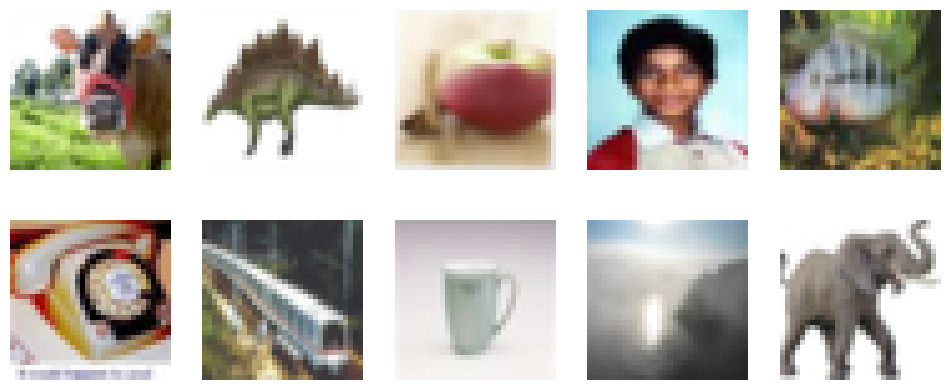

In [ ]:
# Display first 10 images from the training dataset
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(cifar100_train_images[i])
    plt.axis("off")

plt.show()

## 3. Understanding Image Representation

Images are stored as numerical arrays.

Each CIFAR-100 image has shape:

32 × 32 × 3

Where:

- 32 → image height
- 32 → image width
- 3 → RGB color channels

Each pixel contains three values representing:

- Red intensity
- Green intensity
- Blue intensity

These pixel values range from **0 to 255**.

## 4. Data Normalization

We normalize the images by dividing pixel values by **255** so that they fall within the range **0 to 1**.

In [ ]:
cifar100_train_images = cifar100_train_images / 255.0
cifar100_test_images = cifar100_test_images / 255.0

## 5. One-Hot Encoding Labels

The CIFAR-100 dataset contains **100 different classes**.

To train the neural network, labels are converted into **one-hot encoded vectors**.

Example:

Label 7 -

[0,0,0,0,0,0,0,1,0,0,...]

This creates a vector of length **100**, where only the correct class position contains **1** and the rest contain **0**.

In [ ]:
cifar100_train_labels_one_hot = keras.utils.to_categorical(cifar100_train_labels, 100)
cifar100_test_labels_one_hot = keras.utils.to_categorical(cifar100_test_labels, 100)

In [ ]:
# Verify shapes

print("Training images shape:", cifar100_train_images.shape)
print("Testing images shape:", cifar100_test_images.shape)
print("Training labels shape:", cifar100_train_labels_one_hot.shape)
print("Testing labels shape:", cifar100_test_labels_one_hot.shape)

Training images shape: (50000, 32, 32, 3)
Testing images shape: (10000, 32, 32, 3)
Training labels shape: (50000, 100)
Testing labels shape: (10000, 100)


## 6. Model Building

After preprocessing the dataset, the next step is to build a **neural network model** that can learn patterns from the images and classify them into the correct category.

We will use an **Artificial Neural Network (ANN)** for image classification.

The model will take an image as input and predict the correct object category among the **100 classes in the CIFAR-100 dataset**.

In [ ]:
ann_model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(100, activation='softmax')
])
ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,730,404 (6.60 MB)

 Trainable params: 1,730,404 (6.60 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Training the ANN Model

After building and compiling the neural network, the next step is to train the model using the training dataset.



In [ ]:
# Early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
# Save best model weights
model_checkpoint_ann = keras.callbacks.ModelCheckpoint(
    filepath='best_ann_model_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)
print("Training ANN model...")

ann_history = ann_model.fit(
    cifar100_train_images,
    cifar100_train_labels_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(cifar100_test_images, cifar100_test_labels_one_hot),
    callbacks=[early_stopping, model_checkpoint_ann]
)

print("ANN model training finished.")

Training ANN model...
Epoch 1/30
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0505 - loss: 4.3234
Epoch 1: val_loss improved from inf to 3.83534, saving model to best_ann_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.0506 - loss: 4.3225 - val_accuracy: 0.1188 - val_loss: 3.8353
Epoch 2/30
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1286 - loss: 3.7389
Epoch 2: val_loss improved from 3.83534 to 3.62093, saving model to best_ann_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.1287 - loss: 3.7387 - val_accuracy: 0.1557 - val_loss: 3.6209
Epoch 3/30
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1619 - loss: 3.5543
Epoch 3: val_loss improved from 3.62093 to 3.58705, saving model to best_ann_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.1619 - loss: 3.5542 - val_accuracy: 0.1623 - val_loss: 3.5870
Epoch 4/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc

## 8. Model Evaluation

After training the neural network, the model is evaluated using the test dataset.

Model performance is analyzed using the following metrics:

- Accuracy
- Loss
- Confusion Matrix
- Prediction Visualization

These evaluation techniques help us understand how well the model performs and where it makes incorrect predictions.

In [ ]:
# Extract metrics from training history
train_acc = ann_history.history['accuracy']
val_acc = ann_history.history['val_accuracy']

train_loss = ann_history.history['loss']
val_loss = ann_history.history['val_loss']

epochs = list(range(1, len(train_acc) + 1))

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create subplot layout
fig = make_subplots(rows=1, cols=2, subplot_titles=("Accuracy", "Loss"))

# Accuracy curves
fig.add_trace(go.Scatter(x=epochs, y=train_acc, mode='lines', name='Train Accuracy', line=dict(color='cyan', width=3)),row=1, col=1)

fig.add_trace(go.Scatter(x=epochs,y=val_acc,mode='lines',name='Validation Accuracy',line=dict(color='cyan', dash='dot', width=3)),row=1, col=1)

# Loss curves
fig.add_trace(go.Scatter(x=epochs,y=train_loss,mode='lines',name='Train Loss',line=dict(color='magenta', width=3)),row=1, col=2)

fig.add_trace(go.Scatter(x=epochs,y=val_loss,mode='lines',name='Validation Loss',line=dict(color='magenta', dash='dot', width=3)),row=1, col=2)

# Layout styling
fig.update_layout(title="ANN Model Training Performance (Train = Solid, Validation = Dotted)",template="plotly_dark",height=500,width=1100)

fig.show()

## 9. Confusion Matrix

A confusion matrix is a table used to evaluate the performance of a classification model.

It compares the **true labels** of the dataset with the **labels predicted by the model**.

Rows represent the **actual class labels**, while columns represent the **predicted class labels**.

The diagonal values of the matrix indicate **correct predictions**, while off-diagonal values indicate **classification errors**.

A confusion matrix helps identify which classes the model predicts correctly and which classes it tends to confuse.

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
ann_predictions = ann_model.predict(cifar100_test_images)
predicted_labels = np.argmax(ann_predictions, axis=1)
true_labels = np.argmax(cifar100_test_labels_one_hot, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix Shape:", cm.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Confusion Matrix Shape: (100, 100)


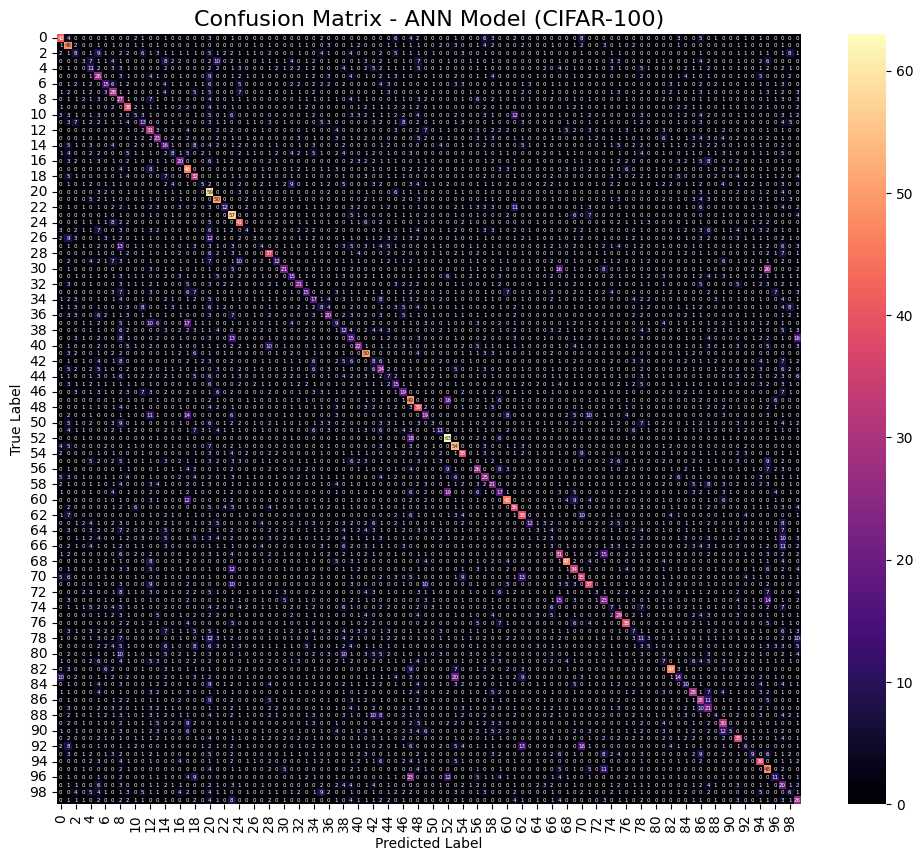

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="magma",
    annot=True,        # show numbers
    fmt="d",           # integer format
    annot_kws={"size":4},  # small text so it fits
    cbar=True
)

plt.title("Confusion Matrix - ANN Model (CIFAR-100)",fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## 10. Visualizing Model Predictions

To further evaluate the model, we visualize some predictions made by the ANN model.

This helps us understand how the model performs on individual images.

In this visualization:

- Correct predictions are displayed with **green titles**
- Incorrect predictions are displayed with **red titles**

For incorrect predictions, the title shows both the **predicted label** and the **true label**.

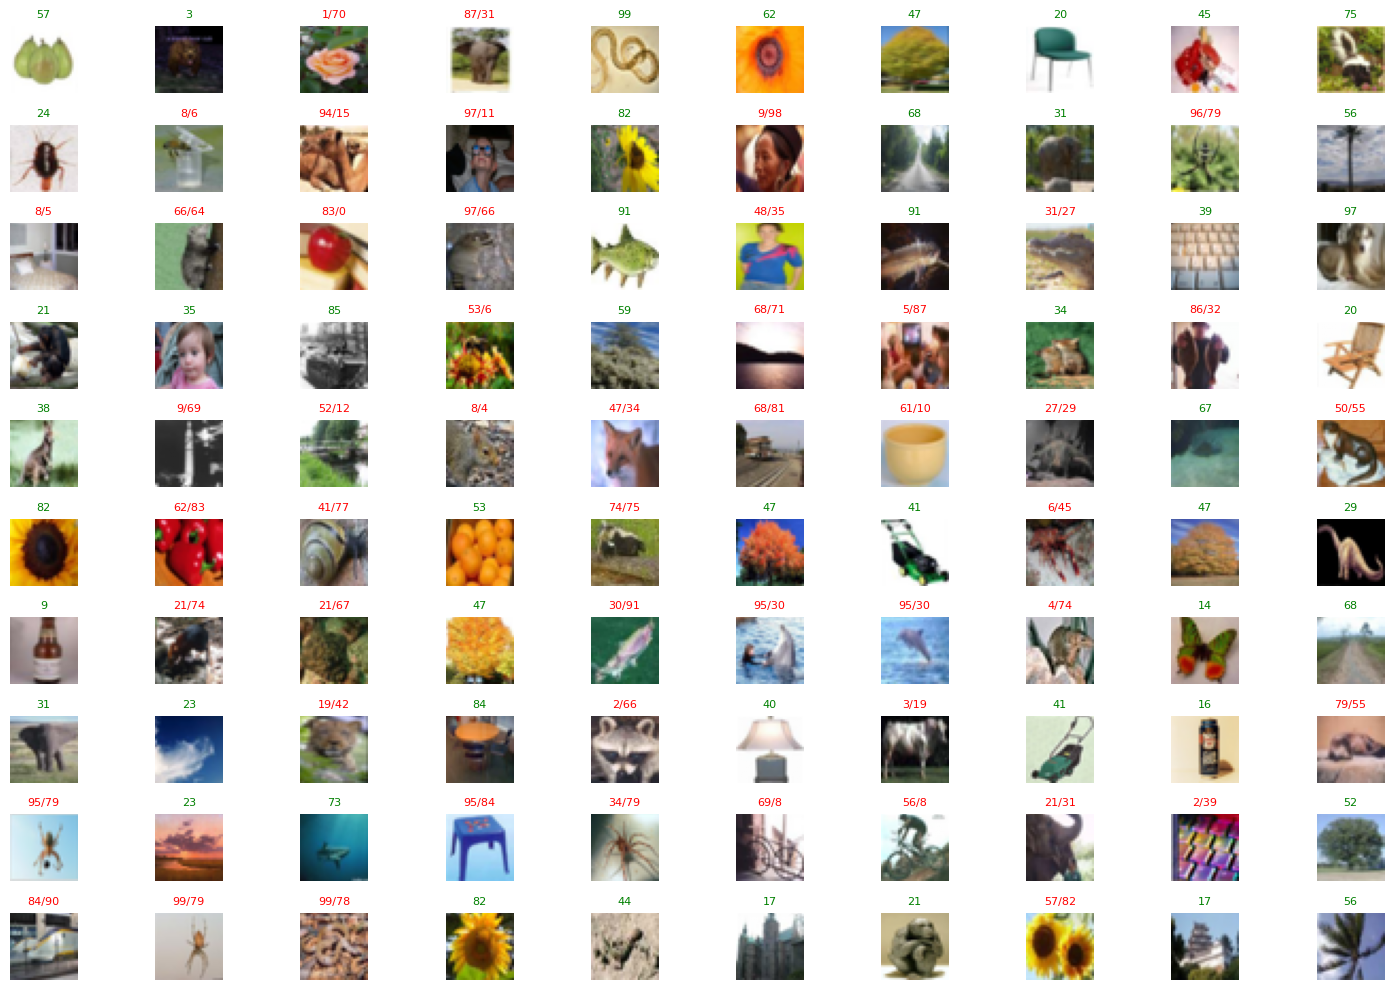

In [ ]:
# Find correct and incorrect predictions

correct_indices = np.where(predicted_labels == true_labels)[0]
incorrect_indices = np.where(predicted_labels != true_labels)[0]
num_correct = min(50, len(correct_indices))
num_incorrect = min(50, len(incorrect_indices))
selected_correct = np.random.choice(correct_indices, num_correct, replace=False)
selected_incorrect = np.random.choice(incorrect_indices, num_incorrect, replace=False)

indices = np.concatenate((selected_correct, selected_incorrect))
np.random.shuffle(indices)

plt.figure(figsize=(15,10))

for i, idx in enumerate(indices[:100]):
    plt.subplot(10,10,i+1)
    plt.imshow(cifar100_test_images[idx])
    plt.axis("off")
    pred = predicted_labels[idx]
    true = true_labels[idx]

    if pred == true:
        plt.title(str(pred), color="green", fontsize=8)
    else:
        plt.title(f"{pred}/{true}", color="red", fontsize=8)

plt.tight_layout()
plt.show()

## Conclusion

- In this project, an Artificial Neural Network (ANN) was implemented to perform image classification on the CIFAR-100 dataset.

- The workflow included dataset loading, preprocessing, neural network construction, model training, and performance evaluation.
